# Exploratory Data Analysis

We have 3 datasets, we quickly go through them and perform basic statistical summaries to get familiar with their structures

## Importing packages

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np

## Exploring files

### Drug synergy dataset

This is the main dataset, it contains information on drug combinations applied to a variety of cell lines. Out of the several read-outs, we are mostly interested in the 'synergy score', an estimate of how the drugs interact with each other:

In [2]:
df=pd.read_csv('data/drug_synergy.csv')
print('Drug synergy: ' + str(df.shape))
df.head()

Drug synergy: (3879, 16)


,Cell line name,Compound A,Compound B,Max. conc. A,Max. conc. B,IC50 A,H A,Einf A,IC50 B,H B,Einf B,Synergy score,QA,Combination ID,Challenge,Dataset
0,BT-20,AKT,ADAM17,1.0,75.0,1.000000,0.809002,59.122436,9.639714,0.757977,91.593425,29.540390,1,ADAM17.AKT,ch1,train
1,CAL-120,AKT,ADAM17,1.0,75.0,0.183214,2.503678,60.411999,1.000000,0.000000,100.000000,4.401410,-1,ADAM17.AKT,ch1,train
2,CAL-51,AKT,ADAM17,1.0,75.0,1.000000,0.726984,11.150843,75.000000,0.375043,76.656479,0.315422,1,ADAM17.AKT,ch1,train
3,DU-4475,AKT,ADAM17,1.0,75.0,0.321533,10.000000,58.599487,75.000000,1.995866,6.171007,-41.734090,-1,ADAM17.AKT,ch1,train
4,HCC1143,AKT,ADAM17,1.0,75.0,0.398673,10.000000,89.098894,1.000000,0.000000,100.000000,35.532770,-1,ADAM17.AKT,ch1,train


we have close to 4k combinatorial experiments described by the first 3 columns.

We use the function `pd.info()` to learn a bit about the dataset:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3879 entries, 0 to 3878
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cell line name  3879 non-null   str    
 1   Compound A      3879 non-null   str    
 2   Compound B      3879 non-null   str    
 3   Max. conc. A    3879 non-null   float64
 4   Max. conc. B    3879 non-null   float64
 5   IC50 A          3879 non-null   float64
 6   H A             3879 non-null   float64
 7   Einf A          3879 non-null   float64
 8   IC50 B          3879 non-null   float64
 9   H B             3879 non-null   float64
 10  Einf B          3879 non-null   float64
 11  Synergy score   3879 non-null   float64
 12  QA              3879 non-null   int64  
 13  Combination ID  3879 non-null   str    
 14  Challenge       3879 non-null   str    
 15  Dataset         3879 non-null   str    
dtypes: float64(9), int64(1), str(6)
memory usage: 485.0 KB


we notice we have no null values and both numerical and categorical features

Another function for summary statistics is `pd.describe()`:

for the categorical features:

In [4]:
df.describe( include='str' ) #descriptive stats for string vars

,Cell line name,Compound A,Compound B,Combination ID,Challenge,Dataset
count,3879,3879,3879,3879,3879,3879
unique,85,54,47,169,1,3
top,CAMA-1,PIK3C,AKT,MAP2K_1.PIK3C,ch1,train
freq,107,407,425,60,3879,2199


from `Cell line name` and `Combination ID` we see that we have 169 experiments, some of them repeated across 85 cell lines. Experiments are determined by the `Compound A` and `Compund B` columns, each having around around 50 unique values. To see how many different drugs are involved we do:

In [5]:
Drugs = list(df['Compound A']) + list(df['Compound B'])
DrugsSet = set(Drugs) #sets keep unique elements only

print('We draw combinations from ' + str( len(DrugsSet) ) + ' drugs')

We draw combinations from 69 drugs


now for the numerical features:

In [6]:
df.describe( include='number' ) #descriptive stats for numerical vars

,Max. conc. A,Max. conc. B,IC50 A,H A,Einf A,IC50 B,H B,Einf B,Synergy score,QA
count,3879.000000,3879.000000,3879.000000,3879.000000,3879.000000,3879.000000,3879.000000,3879.000000,3879.000000,3879.000000
mean,1.721684,4.960581,0.733284,2.900107,45.668832,1.464394,2.902762,48.091803,10.236308,0.758443
std,1.818286,14.657023,1.021671,3.634496,36.089669,6.479483,3.704492,35.876790,116.249064,0.742968
min,0.003000,0.003000,0.000003,0.000000,0.000000,0.000001,0.000000,0.000000,-588.220700,-3.000000
25%,1.000000,1.000000,0.069179,0.507272,11.283196,0.133534,0.432883,12.537512,-5.246305,1.000000
50%,1.000000,1.000000,0.337817,1.264897,40.799162,0.491043,1.177369,47.599717,8.429529,1.000000
75%,3.000000,3.000000,1.000000,2.989752,81.543462,1.000000,3.014471,82.398922,25.385300,1.000000
max,10.000000,75.000000,10.000000,10.000000,100.000000,75.000000,10.000000,100.000000,6737.175000,1.000000


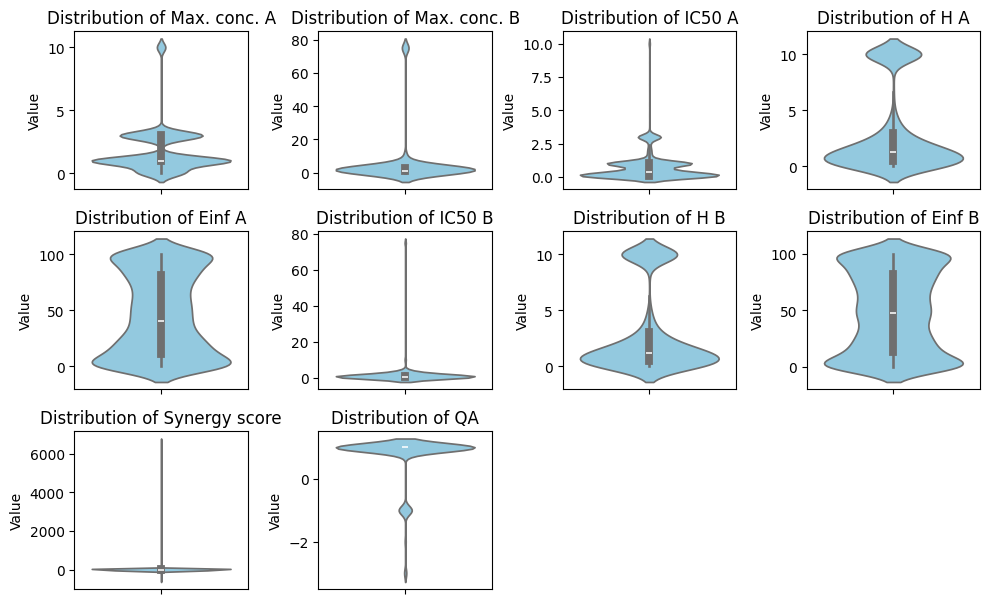

In [7]:
#Filter num data
cols = df.select_dtypes(include='number')
n_cols = len(cols)

#Setup fig grid
grid_cols = 4
grid_rows = math.ceil( n_cols / grid_cols )

fig, axes = plt.subplots( grid_rows, grid_cols, figsize=(10, grid_rows * 2) )
axes = axes.flatten()  #to iterate

#Plot each var on its own axis
for i, col in enumerate(cols):
    sns.violinplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Value')

#Remove empty subplots if exist
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Prevent overlapping labels
plt.show()

we notice that `Synergy score` is quite spread, so a log based normalization might be required.

### Cell lines dataset

This dataset contains extra information on cell lines:

In [8]:
cell_lines_df=pd.read_csv('data/cell_lines.csv')
print('Cell lines dataset size: ' + str(cell_lines_df.shape))
cell_lines_df.head()

Cell lines dataset size: (159, 10)


,Cell line name,COSMIC ID,GDSC tissue descriptor 1,GDSC tissue descriptor 2,TCGA label,MSI,Growth properties,AZ-DREAM,O'Neil et al. 2016,ALMANAC
0,22RV1,924100,urogenital_system,prostate,PRAD,MSI-H,Adherent,1.0,0.0,0.0
1,647-V,906797,urogenital_system,Bladder,BLCA,MSS/MSI-L,Adherent,1.0,0.0,0.0
2,786-0,905947,kidney,kidney,KIRC,MSS/MSI-L,Adherent,0.0,0.0,1.0
3,A2058,906792,skin,melanoma,SKCM,MSS/MSI-L,Adherent,0.0,1.0,0.0
4,A2780,906804,urogenital_system,ovary,UNABLE TO CLASSIFY,MSS/MSI-L,Semi-Adherent,0.0,1.0,0.0


we apply summary statistics again:

In [9]:
cell_lines_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Cell line name            159 non-null    str    
 1   COSMIC ID                 159 non-null    int64  
 2   GDSC tissue descriptor 1  159 non-null    str    
 3   GDSC tissue descriptor 2  159 non-null    str    
 4   TCGA label                151 non-null    str    
 5   MSI                       158 non-null    str    
 6   Growth properties         159 non-null    str    
 7   AZ-DREAM                  144 non-null    float64
 8   O'Neil et al. 2016        144 non-null    float64
 9   ALMANAC                   144 non-null    float64
dtypes: float64(3), int64(1), str(6)
memory usage: 12.5 KB


this time we do have null values in several columns, and again both numerical and categorical features

In [10]:
cell_lines_df.describe( include='str' ) 

,Cell line name,GDSC tissue descriptor 1,GDSC tissue descriptor 2,TCGA label,MSI,Growth properties
count,159,159,159,151,158,159
unique,144,12,19,18,2,3
top,SW837,breast,breast,BRCA,MSS/MSI-L,Adherent
freq,2,37,37,36,144,142


In [11]:
cell_lines_df.describe( include='number' ) 

,COSMIC ID,AZ-DREAM,O'Neil et al. 2016,ALMANAC
count,1.590000e+02,144.000000,144.000000,144.000000
mean,8.954344e+05,0.590278,0.215278,0.409722
std,1.306580e+05,0.493499,0.412450,0.493499
min,6.874550e+05,0.000000,0.000000,0.000000
25%,9.059425e+05,0.000000,0.000000,0.000000
50%,9.059800e+05,1.000000,0.000000,0.000000
75%,9.084515e+05,1.000000,0.000000,1.000000
max,1.659817e+06,1.000000,1.000000,1.000000


we have information on 159 cell lines, although not the same info for all of them. Remember the main dataset contained 85. We leave further exploration until the feature selection section.

### Drug portfolio dataset

This dataset contains information on the drugs. 

To properly read this file, we first need to figure out the separator between values (notice it doesn't render properly on github):

In [12]:
with open('data/drug_portfolio.csv') as f:
    lines = [line.rstrip() for line in f.readlines()] #list of lines on f
    
for l in lines[:5]: #print a few, let's see if we notice a pattern
    print(repr(l)) 

'Drug name\tChallenge drug name\tPutative target\tFunction\tPathway\tHBA\tHBD\tMolecular weight\tcLogP\tLipinski\tSMILES'
'MEDI3622\tADAM17\tADAM17\tDifferentiation\tEMT/migration\t-\t-\t-\t-\t-\tAntibody (MEDI3622)'
'AZD5363\tAKT\tAKT1;AKT2;AKT3\tOncogenic signal\tAKT/PI3K\t8\t5\t428.9\t1.18\t0\tc1cc(ccc1[C@H](CCO)NC(=O)C2(CCN(CC2)c3c4cc[nH]c4ncn3)N)Cl'
'MK2206\tAKT_1\tAKT*\tOncogenic signal\tAKT/PI3K\t6\t3\t407.5\t3.24\t0\tc1ccc(cc1)c2cc3c(ccn4c3n[nH]c4=O)nc2c5ccc(cc5)C6(CCC6)N'
'Perifosine,KRX-0401\tAKT_PIK3C\tAKT*;PIK3C*\tOncogenic signal\tAKT/PI3K\tNA\tNA\tNA\tNA\tNA\tNA'


and we see it's `tab`. Then:

In [13]:
drug_portfolio_df=pd.read_csv('data/drug_portfolio.csv', sep='\t')
print('Drug portfolio dataset size: ' + str(drug_portfolio_df.shape))
drug_portfolio_df.head()

Drug portfolio dataset size: (118, 11)


,Drug name,Challenge drug name,Putative target,Function,Pathway,HBA,HBD,Molecular weight,cLogP,Lipinski,SMILES
0,MEDI3622,ADAM17,ADAM17,Differentiation,EMT/migration,-,-,-,-,-,Antibody (MEDI3622)
1,AZD5363,AKT,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,8,5,428.9,1.18,0,c1cc(ccc1[C@H](CCO)NC(=O)C2(CCN(CC2)c3c4cc[nH]...
2,MK2206,AKT_1,AKT*,Oncogenic signal,AKT/PI3K,6,3,407.5,3.24,0,c1ccc(cc1)c2cc3c(ccn4c3n[nH]c4=O)nc2c5ccc(cc5)...
3,"Perifosine,KRX-0401",AKT_PIK3C,AKT*;PIK3C*,Oncogenic signal,AKT/PI3K,NaN,NaN,NaN,NaN,NaN,NaN
4,"AZ13409007, AKTaz",AKT_SGK,AKT*;SGK*,Oncogenic signal,AKT/PI3K,8,3,459.3,2.25,0,COc1cc2c(cc1OC)C3(CCN(CC3)c4c5c([nH]nc5Br)ncn4...


as before, we do some summary statistics:

In [14]:
drug_portfolio_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Drug name            115 non-null    str  
 1   Challenge drug name  118 non-null    str  
 2   Putative target      118 non-null    str  
 3   Function             118 non-null    str  
 4   Pathway              118 non-null    str  
 5   HBA                  63 non-null     str  
 6   HBD                  63 non-null     str  
 7   Molecular weight     63 non-null     str  
 8   cLogP                63 non-null     str  
 9   Lipinski             63 non-null     str  
 10  SMILES               63 non-null     str  
dtypes: str(11)
memory usage: 10.3 KB


we have a lot of null values here; also, all features are strings.

In [16]:
drug_portfolio_df.describe( include='str' )

,Drug name,Challenge drug name,Putative target,Function,Pathway,HBA,HBD,Molecular weight,cLogP,Lipinski,SMILES
count,115,118,118,118,118,63,63,63,63,63,63
unique,115,118,84,6,13,13,8,59,58,5,63
top,MEDI3622,ADAM17,DNA,Oncogenic signal,AKT/PI3K,7,1,412.5,4.29,0,Antibody (MEDI3622)
freq,1,1,6,59,22,15,18,2,3,42,1


so we have information on 115 drugs, although not the same info on all. Remember the main dataset contained combinations of 69 different drugs.

## Preprocesing and feature selection

We follow the feature selection criteria of the original paper, aiming for comparisons later on. Some of the features and experiments are dropped according to:

* Keep only experiments with high quality, `QA == 1 `
* Remove features with over 20% missing values: `HBA`, `HBD`, `Molecular weight`, `cLogP`, `Lipinski`, `SMILES`
* Remove 'unnercesary or redundant' columns. According to the study, these are: `Challenge`, `QA`, `COSMIC ID`, `GDSC tissue descriptor 1`, `TCGA`, `Dataset`

Then:

In [17]:
#Quality filtering
df = df[df.QA==1]
df

,Cell line name,Compound A,Compound B,Max. conc. A,Max. conc. B,IC50 A,H A,Einf A,IC50 B,H B,Einf B,Synergy score,QA,Combination ID,Challenge,Dataset
0,BT-20,AKT,ADAM17,1.00,75.0,1.000000,0.809002,59.122436,9.639714,0.757977,91.593425,29.540390,1,ADAM17.AKT,ch1,train
2,CAL-51,AKT,ADAM17,1.00,75.0,1.000000,0.726984,11.150843,75.000000,0.375043,76.656479,0.315422,1,ADAM17.AKT,ch1,train
5,HCC1187,AKT,ADAM17,1.00,75.0,0.410029,1.496901,51.921265,1.000000,0.000000,100.000000,-0.801993,1,ADAM17.AKT,ch1,train
7,HCC1806,AKT,ADAM17,1.00,75.0,0.313992,10.000000,63.399635,75.000000,0.392570,48.650054,-26.733250,1,ADAM17.AKT,ch1,train
8,HCC1937,AKT,ADAM17,1.00,75.0,1.000000,0.771830,41.529554,1.677924,1.119487,92.188029,32.165520,1,ADAM17.AKT,ch1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3874,Calu-6,Vinorelbine,BCL2_2,0.03,3.0,0.015602,2.583210,36.854102,1.000000,0.000000,100.000000,12.384880,1,BCL2_2.Vinorelbine,ch1,test
3875,NCI-H1563,Vinorelbine,BCL2_2,0.03,3.0,0.030000,0.110001,29.776107,0.000300,0.100000,88.601043,-115.750900,1,BCL2_2.Vinorelbine,ch1,test
3876,NCI-H2085,Vinorelbine,BCL2_2,3.00,3.0,0.003088,0.241204,28.470279,1.000000,0.000000,100.000000,-8.649973,1,BCL2_2.Vinorelbine,ch1,test
3877,NCI-H23,Vinorelbine,BCL2_2,0.10,3.0,0.030085,10.000000,15.199403,1.000000,0.000000,100.000000,31.952940,1,BCL2_2.Vinorelbine,ch1,test


In [94]:
#missing vals fitlering
df1log = (df1.isna().sum() < len(df1)*0.2).values #logical vector, T if less than 20% missing values
df2log = (df2.isna().sum() < len(df2)*0.2).values
df3log = (df3.isna().sum() < len(df3)*0.2).values

df1 = df1[ df1.columns[df1log] ]
df2 = df2[ df2.columns[df2log] ]
df3 = df3[ df3.columns[df3log] ]

df3

,Drug name,Challenge drug name,Putative target,Function,Pathway
0,MEDI3622,ADAM17,ADAM17,Differentiation,EMT/migration
1,AZD5363,AKT,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K
2,MK2206,AKT_1,AKT*,Oncogenic signal,AKT/PI3K
3,"Perifosine,KRX-0401",AKT_PIK3C,AKT*;PIK3C*,Oncogenic signal,AKT/PI3K
4,"AZ13409007, AKTaz",AKT_SGK,AKT*;SGK*,Oncogenic signal,AKT/PI3K
...,...,...,...,...,...
113,"5FU,Fluorouracil",TYMS,TYMS,DNA repair,Cell Cycle
114,"AZD2171,Recentin,Cediranib",VEGF,KDR;FLT1;FLT4,Differentiation,EMT/migration
115,Vinorelbine,Vinorelbine,microtubule;TUBB,DNA repair,Chemo
116,AZD1775,WEE1,WEE1,DNA repair,DNA Damage Response


In [21]:
#irrelevant features filtering
badfeats = ['Challenge', 'QA', 'COSMIC ID', 'GDSC tissue descriptor 1', 'TCGA','Dataset']

#filter irrelevant features
def filterfunc( df ):
    ''' Takes a df and checks its cols, if they in badfeats, they are removed '''
    tobedropped = []
    for col in df.columns:
        if col in badfeats:
            tobedropped.append(col)
    
    df = df.drop( tobedropped, axis=1 )
    return df

df = filterfunc(df)
cell_lines_df = filterfunc(cell_lines_df)
drug_portfolio_df = filterfunc(drug_portfolio_df)

print( 'Final features \n' )
print( 'Drug combinations: ', df.columns )
print( 'Cell lines: ', cell_lines_df.columns)
print( 'Drug portfolio: ', drug_portfolio_df.columns)

Final features 

Drug combinations:  Index(['Cell line name', 'Compound A', 'Compound B', 'Max. conc. A',
       'Max. conc. B', 'IC50 A', 'H A', 'Einf A', 'IC50 B', 'H B', 'Einf B',
       'Synergy score', 'Combination ID'],
      dtype='str')
Cell lines:  Index(['Cell line name', 'GDSC tissue descriptor 2', 'TCGA label', 'MSI',
       'Growth properties', 'AZ-DREAM ', 'O'Neil et al. 2016', 'ALMANAC'],
      dtype='str')
Drug portfolio:  Index(['Drug name', 'Challenge drug name', 'Putative target', 'Function',
       'Pathway', 'HBA', 'HBD', 'Molecular weight', 'cLogP', 'Lipinski',
       'SMILES'],
      dtype='str')


We continue following the paper. We integrate information from `cell_lines_df` and from `drug_portfolio_df` into the drug combinations dataset:

* From the cell lines df: `GDSC tissue descriptor 2`, `MSI`, `Growth properties`.
* From the drug portfolio df: `Putative target`, `Function`, `Pathway`, for each drug. Notice, this means we need 6 columns in total, 3 for `Compound A` and 3 for `Compund B`

In [25]:
#cell line, drugA and drug B dfs
cell_lines_df = cell_lines_df[ ['Cell line name', 'GDSC tissue descriptor 2', 'MSI', 'Growth properties'] ]
cell_lines_df.drop_duplicates( inplace=True ) #as we removed some columns, we might have duplicate rows

drug_portfolio_df_A = drug_portfolio_df[ ['Drug name', 'Putative target','Function', 'Pathway'] ]
drug_portfolio_df_A.columns = ['Compound A', 'Putative target A','Function A', 'Pathway A'] #rename
drug_portfolio_df_A.drop_duplicates( inplace=True )

drug_portfolio_df_B = drug_portfolio_df[ ['Drug name', 'Putative target','Function', 'Pathway'] ]
drug_portfolio_df_B.columns = ['Compound B', 'Putative target B','Function B', 'Pathway B'] #rename
drug_portfolio_df_B.drop_duplicates( inplace=True )

#join on drug combination df
df = pd.merge( df, cell_lines_df, how='left', on='Cell line name' ) #add cell line info
df = pd.merge( df, drug_portfolio_df_A, how='left', on='Compound A' ) #add drug A info
df = pd.merge( df, drug_portfolio_df_B, how='left', on='Compound B' ) #add drug B info

df

,Cell line name,Compound A,Compound B,Max. conc. A,Max. conc. B,IC50 A,H A,Einf A,IC50 B,H B,...,Growth properties_y,GDSC tissue descriptor 2,MSI,Growth properties,Putative target A,Function A,Pathway A,Putative target B,Function B,Pathway B
0,BT-20,AKT,ADAM17,1.00,75.0,1.000000,0.809002,59.122436,9.639714,0.757977,...,Adherent,breast,MSS/MSI-L,Adherent,NaN,NaN,NaN,NaN,NaN,NaN
1,CAL-51,AKT,ADAM17,1.00,75.0,1.000000,0.726984,11.150843,75.000000,0.375043,...,Adherent,breast,MSS/MSI-L,Adherent,NaN,NaN,NaN,NaN,NaN,NaN
2,HCC1187,AKT,ADAM17,1.00,75.0,0.410029,1.496901,51.921265,1.000000,0.000000,...,Suspension,breast,MSS/MSI-L,Suspension,NaN,NaN,NaN,NaN,NaN,NaN
3,HCC1806,AKT,ADAM17,1.00,75.0,0.313992,10.000000,63.399635,75.000000,0.392570,...,Adherent,breast,MSS/MSI-L,Adherent,NaN,NaN,NaN,NaN,NaN,NaN
4,HCC1937,AKT,ADAM17,1.00,75.0,1.000000,0.771830,41.529554,1.677924,1.119487,...,Adherent,breast,MSS/MSI-L,Adherent,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3470,Calu-6,Vinorelbine,BCL2_2,0.03,3.0,0.015602,2.583210,36.854102,1.000000,0.000000,...,Adherent,lung_NSCLC_adenocarcinoma,MSS/MSI-L,Adherent,microtubule;TUBB,DNA repair,Chemo,NaN,NaN,NaN
3471,NCI-H1563,Vinorelbine,BCL2_2,0.03,3.0,0.030000,0.110001,29.776107,0.000300,0.100000,...,Adherent,lung_NSCLC_adenocarcinoma,MSS/MSI-L,Adherent,microtubule;TUBB,DNA repair,Chemo,NaN,NaN,NaN
3472,NCI-H2085,Vinorelbine,BCL2_2,3.00,3.0,0.003088,0.241204,28.470279,1.000000,0.000000,...,Adherent,lung_NSCLC_adenocarcinoma,MSS/MSI-L,Adherent,microtubule;TUBB,DNA repair,Chemo,NaN,NaN,NaN
3473,NCI-H23,Vinorelbine,BCL2_2,0.10,3.0,0.030085,10.000000,15.199403,1.000000,0.000000,...,Adherent,lung_NSCLC_adenocarcinoma,MSS/MSI-L,Adherent,microtubule;TUBB,DNA repair,Chemo,NaN,NaN,NaN


## Visualization

We finalize this section visually exploring some of the relationships between the dataset's features, particularly their relation with the Synergy Score: